# RQ3 — Citation accuracy: when an engine cites my content, is it telling the truth?

Five figures on how faithfully each engine represents sources when it cites them, measured by the **cleaned**
AIS (Attributable-to-Identified-Sources rate) and the underlying NLI entailment scores. Shared style, palette,
data and validators live in the first code cell; every figure below is one compact cell followed by a
plain-English **Key analysis**.

In [1]:
# === RQ3 shared preamble: style (Visual_Style_Guide §13 + §5), data, helpers, validators ===
import os, logging, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
warnings.filterwarnings("ignore"); logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ---- §13 matplotlib global configuration block (verbatim) ----
# --- Font ---
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Calibri", "DejaVu Sans", "Arial"]
mpl.rcParams["font.size"] = 11
# --- Axes ---
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.edgecolor"] = "#374151"
mpl.rcParams["axes.linewidth"] = 0.8
mpl.rcParams["axes.labelpad"] = 10
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.labelweight"] = "medium"
# --- Grid ---
mpl.rcParams["axes.grid"] = True
mpl.rcParams["axes.grid.axis"] = "y"
mpl.rcParams["grid.color"] = "#E5E7EB"
mpl.rcParams["grid.linewidth"] = 0.5
mpl.rcParams["grid.linestyle"] = "--"
mpl.rcParams["axes.axisbelow"] = True
# --- Ticks ---
mpl.rcParams["xtick.direction"] = "out"
mpl.rcParams["ytick.direction"] = "out"
mpl.rcParams["xtick.major.size"] = 4
mpl.rcParams["ytick.major.size"] = 4
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
# --- Legend ---
mpl.rcParams["legend.frameon"] = False
mpl.rcParams["legend.fontsize"] = 11
# --- Figure ---
mpl.rcParams["figure.figsize"] = (7, 4.5)
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["savefig.pad_inches"] = 0.15
# --- Engine palette ---
ENGINE_COLOURS = {
    "chatgpt":    "#2CA058",
    "claude":     "#D97706",
    "gemini":     "#2563EB",
    "kimi":       "#7C3AED",
    "perplexity": "#0891B2",
}
ENGINE_ORDER = ["chatgpt", "claude", "gemini", "kimi", "perplexity"]
ENGINE_LABELS = {
    "chatgpt":    "ChatGPT",
    "claude":     "Claude",
    "gemini":     "Gemini",
    "kimi":       "Kimi",
    "perplexity": "Perplexity",
}
ENGINE_MARKERS = {
    "chatgpt":    "o",
    "claude":     "s",
    "gemini":     "^",
    "kimi":       "D",
    "perplexity": "X",
}
# --- Supplementary colours ---
COLOUR_PRIMARY   = "#1F4E79"
COLOUR_NEUTRAL   = "#6B7280"
COLOUR_REFERENCE = "#DC2626"
COLOUR_GRID      = "#E5E7EB"
# --- Sequential heatmap ramp (teal-blue) ---
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list("teal_sequential", ["#EAF0F7", "#5B8AC4", "#1F4E79"])
CMAP_SEQUENTIAL.set_bad("#D1D5DB")
# --- Divergent ramp (amber-brown -> white -> teal) for signed quantities ---
CMAP_DIVERGENT = LinearSegmentedColormap.from_list("teal_divergent", ["#B45309", "#F3F4F6", "#1F4E79"])

# ---- §5 apply_style ----
def apply_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#374151")
    ax.spines["bottom"].set_color("#374151")
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--")
    ax.set_axisbelow(True)
    ax.tick_params(direction="out", length=4, labelsize=11)

# ---- data load (CLEANED metrics only) ----
GOLD = "../../data/scaleup/gold"; FIGDIR = "../../figures/scaleup/rq"; os.makedirs(FIGDIR, exist_ok=True)
ca = pd.read_parquet(f"{GOLD}/cell_aggregates_scaleup.parquet")             # per-cell workhorse, 1,249 rows
f1 = pd.read_parquet(f"{GOLD}/flat_table1_responses.parquet")              # per-run, 9,992 rows
f4 = pd.read_parquet(f"{GOLD}/flat_table4_entailment_scores.parquet")      # per citation entailment, 1.18M rows
qf = pd.read_parquet("../../data/scaleup/queries/reclass_queries.parquet")[["query_id", "intent"]]

# ---- helpers ----
def savefig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(f"{FIGDIR}/{name}.{ext}")
    print("saved", name)

def by_engine(s):
    return s.reindex(ENGINE_ORDER)

# ---- validators (counts + cell-level reconciliation TWO ways + documented NaN/zero totals) ----
def validate():
    assert sorted(ca.engine.unique()) == ENGINE_ORDER and ca.query_id.nunique() == 250
    assert len(ca) == 1249 and len(f1) == 9992, (len(ca), len(f1))
    assert set(ca.n_runs.unique()) == {8}
    print(f"[warn] {1250 - len(ca)} missing cell: kimi/gb_3fcf760b1a2ea4f8 (expected)")
    rows = []
    for c_ca, c_f1 in [("ais_mean", "cleaned_ais"), ("pawc_norm_mean", "pawc_norm")]:
        recon = f1.groupby(["engine", "query_id"])[c_f1].mean()             # cell mean skips NaN within cell
        gold = ca.set_index(["engine", "query_id"])[c_ca]
        assert (gold.isna() == recon.isna()).all(), c_ca
        d = (gold - recon).abs().max(); assert d < 1e-9, (c_ca, d)
        rows.append((c_ca, "vs re-aggregated flat_table1 (skipna)", f"{d:.1e}", "PASS"))
    n_zero = int((ca.pawc_norm_mean.isna() | (ca.pawc_norm_mean == 0)).sum())
    assert n_zero == 273 and int(ca.ais_cv.isna().sum()) == 273
    assert f4.response_id.isin(set(f1.response_id)).all() and int(f4.entail_score.isna().sum()) == 0
    assert f4.entail_score.between(0, 1).all()
    print(pd.DataFrame(rows, columns=["metric", "check", "max|diff|", "ok"]).to_string(index=False))
    print(f"zero-prominence cells={n_zero} | ais_cv NaN=273 | entail rows={len(f4):,} all mapped & in [0,1]  PASS")
validate()

[warn] 1 missing cell: kimi/gb_3fcf760b1a2ea4f8 (expected)
        metric                                 check max|diff|   ok
      ais_mean vs re-aggregated flat_table1 (skipna)   1.1e-16 PASS
pawc_norm_mean vs re-aggregated flat_table1 (skipna)   1.1e-16 PASS
zero-prominence cells=273 | ais_cv NaN=273 | entail rows=1,181,792 all mapped & in [0,1]  PASS


saved fig_rq3_q12_ais_per_engine


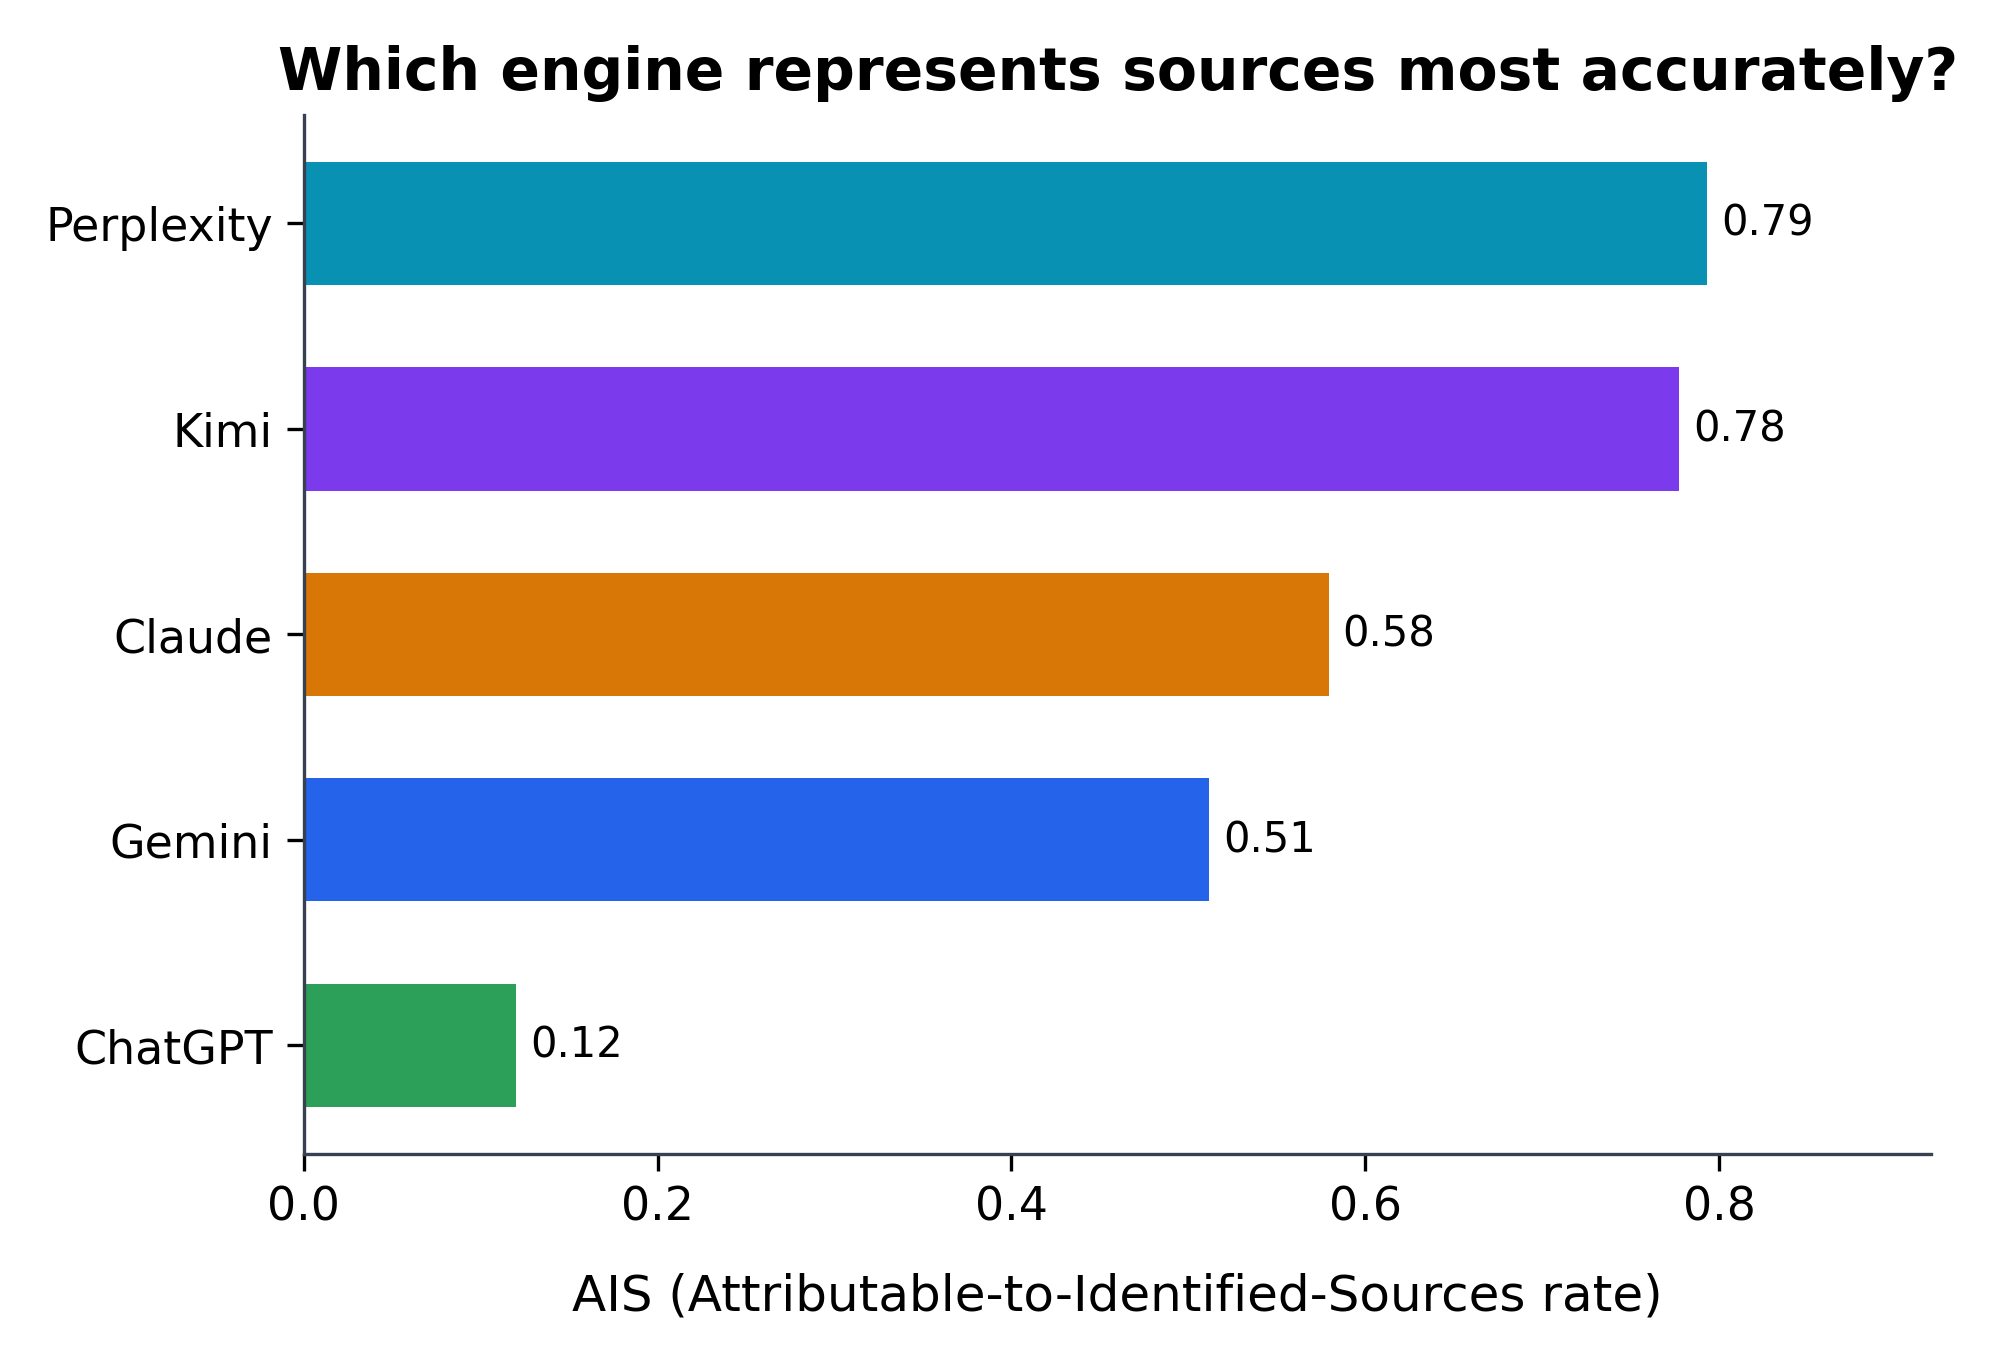

In [2]:
# Q12 · Mean AIS per engine across all 250 queries (cleaned ais_mean). Horizontal bars, sorted desc, value labels.
s = by_engine(ca.groupby("engine").ais_mean.mean()).sort_values()                  # asc -> highest ends on top
assert (s - by_engine(f1.groupby("engine").cleaned_ais.mean()).reindex(s.index)).abs().max() < 2e-3  # cell- vs response-weighted
fig, ax = plt.subplots()
ax.barh([ENGINE_LABELS[e] for e in s.index], s.values, height=0.6, color=[ENGINE_COLOURS[e] for e in s.index])
for y, val in enumerate(s.values):
    ax.text(val + 0.008, y, f"{val:.2f}", va="center", fontsize=10)
ax.set_xlabel("AIS (Attributable-to-Identified-Sources rate)")
ax.set_title("Which engine represents sources most accurately?")
ax.set_xlim(0, 0.92); apply_style(ax); ax.grid(False)
savefig(fig, "fig_rq3_q12_ais_per_engine")

**Key analysis.** Each bar is one engine's average AIS — the share of its **answer sentences** that are backed
by a source it cites (every sentence counts, so leaving claims uncited lowers the score, not just citing them
wrongly). **Perplexity (0.79) and Kimi (0.78) lead; ChatGPT sits far below at 0.12.** ChatGPT's figure is real but
mostly a coverage problem: about 79% of its sentences carry no citation at all, so most of its answer is unsourced
— and even the sentences it does cite are supported only ~56% of the time, the weakest of any engine. Action:
Perplexity and Kimi ground almost everything they say, so their citations can be trusted; treat most of a ChatGPT
answer as unsourced and check its claims yourself.

saved fig_rq3_q13_entail_bands


saved fig_rq3_q13_entail_bands_appendix


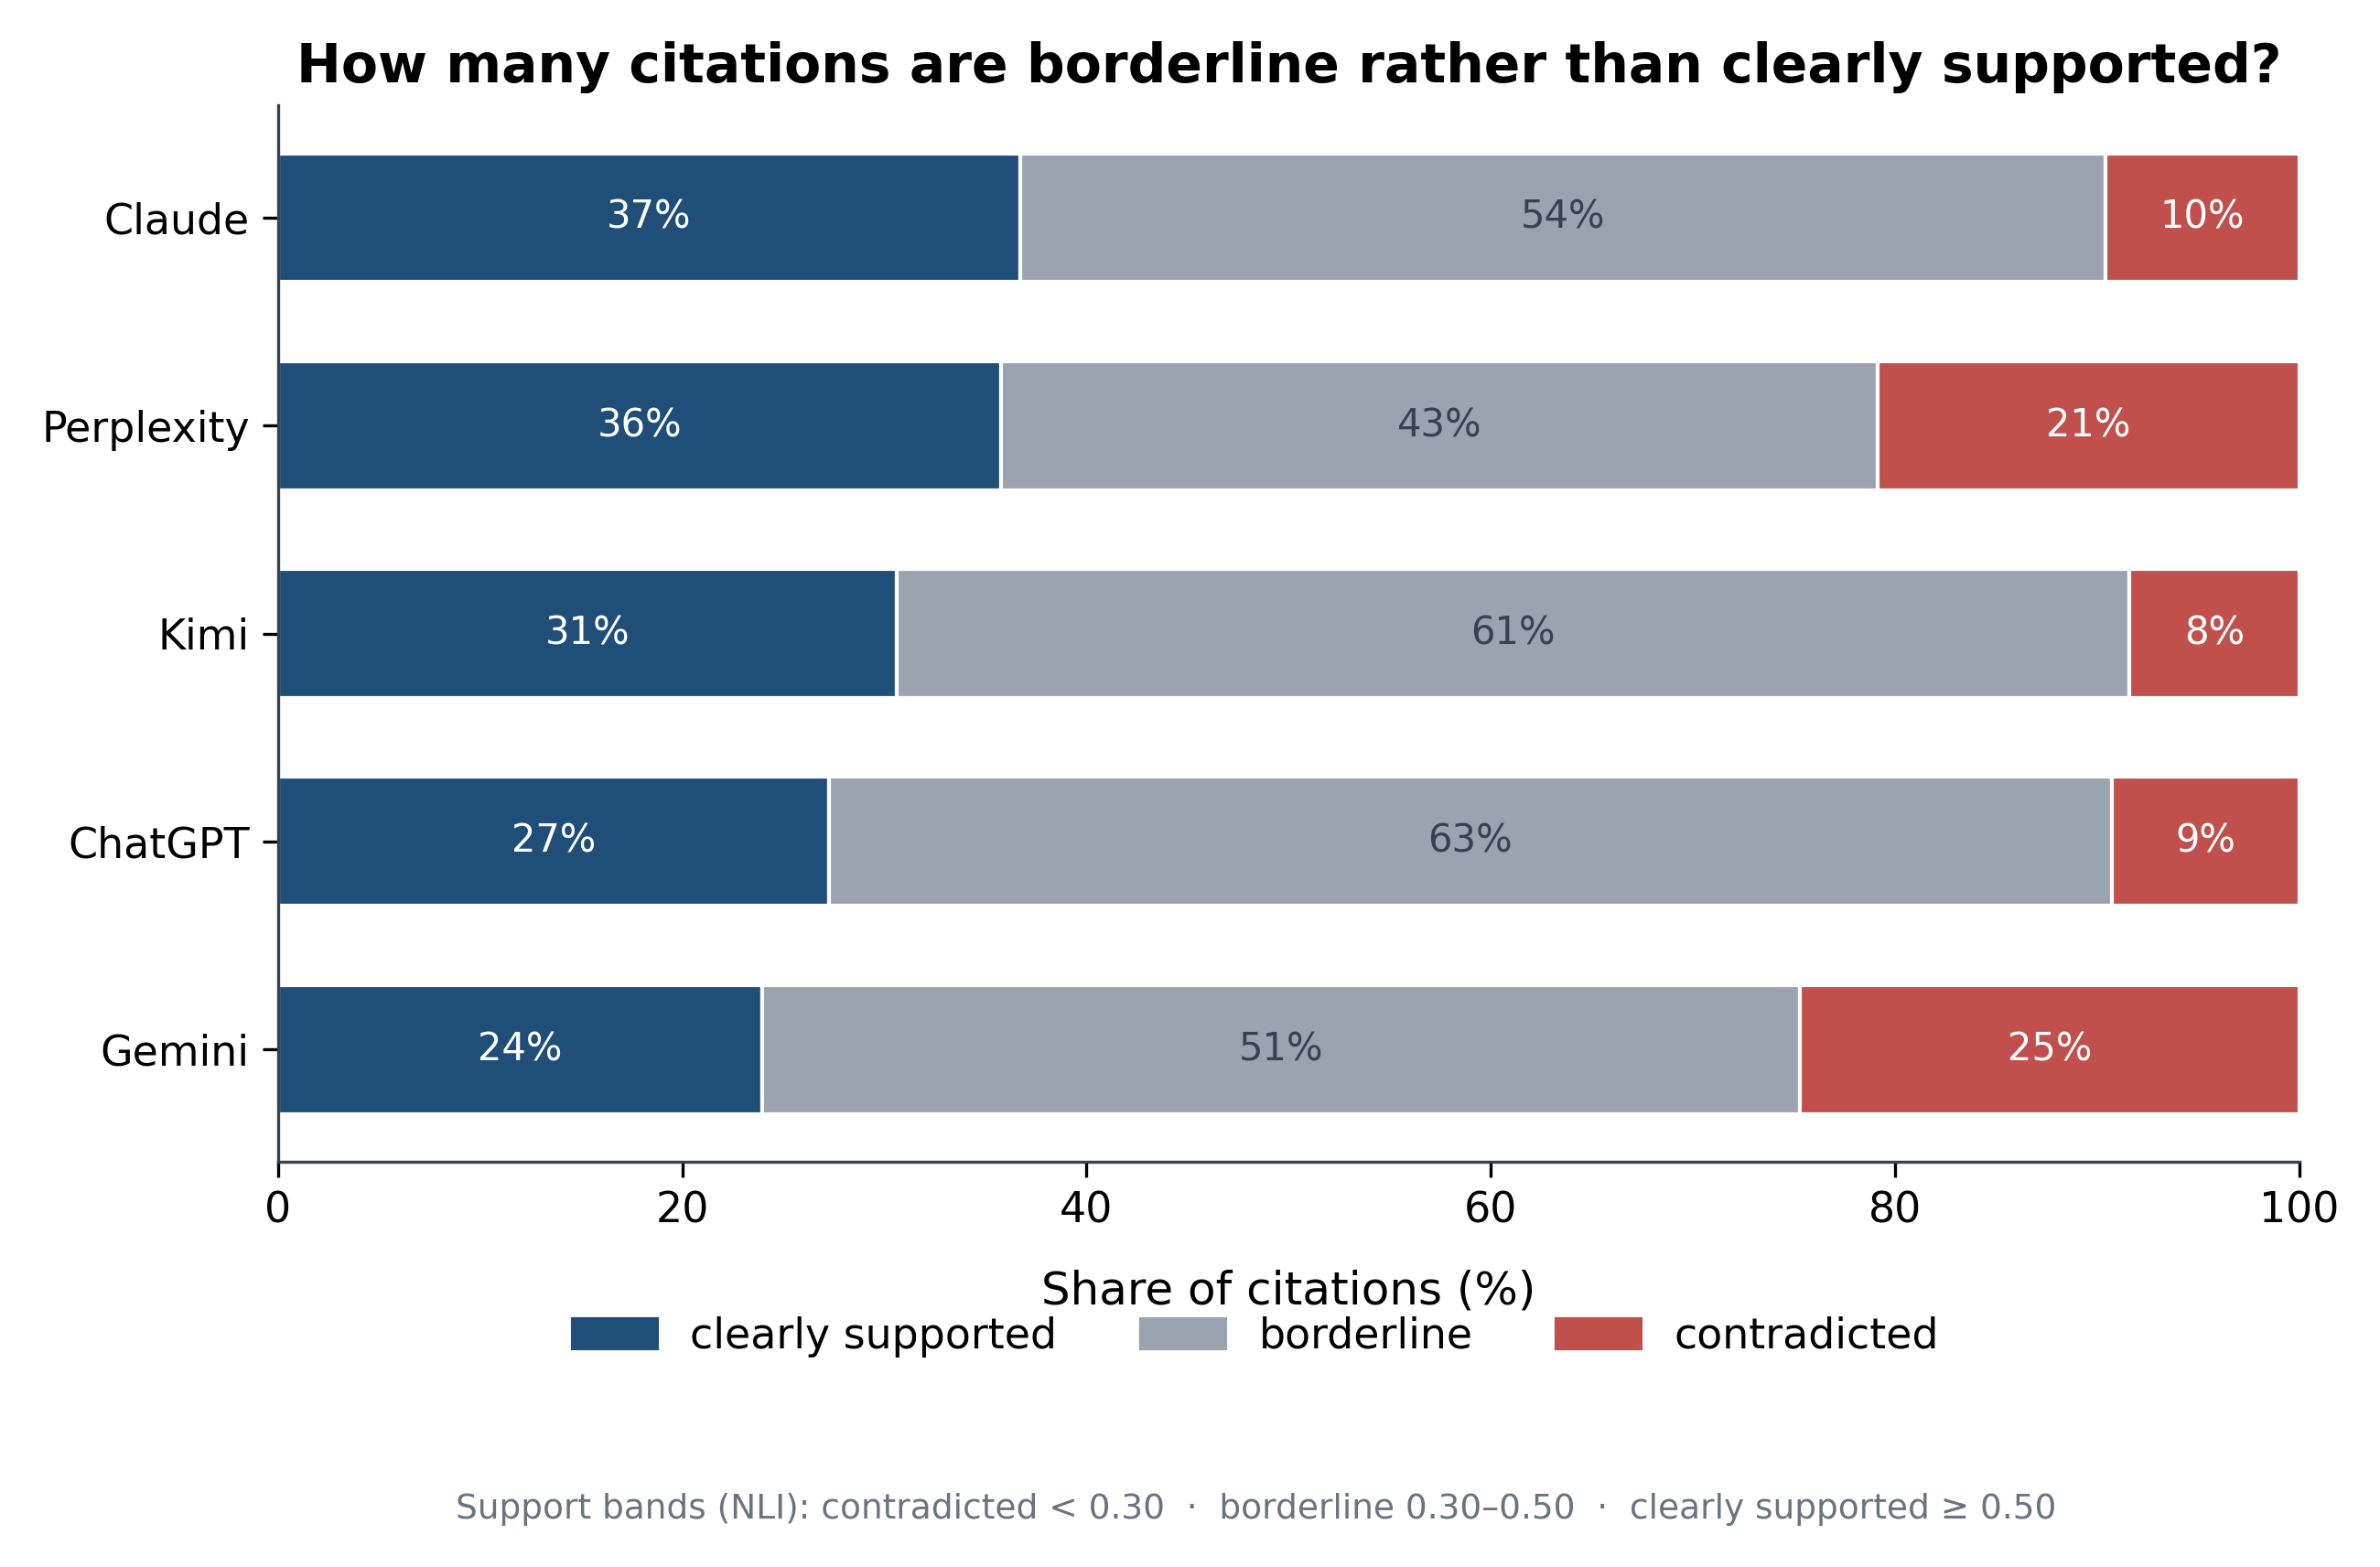

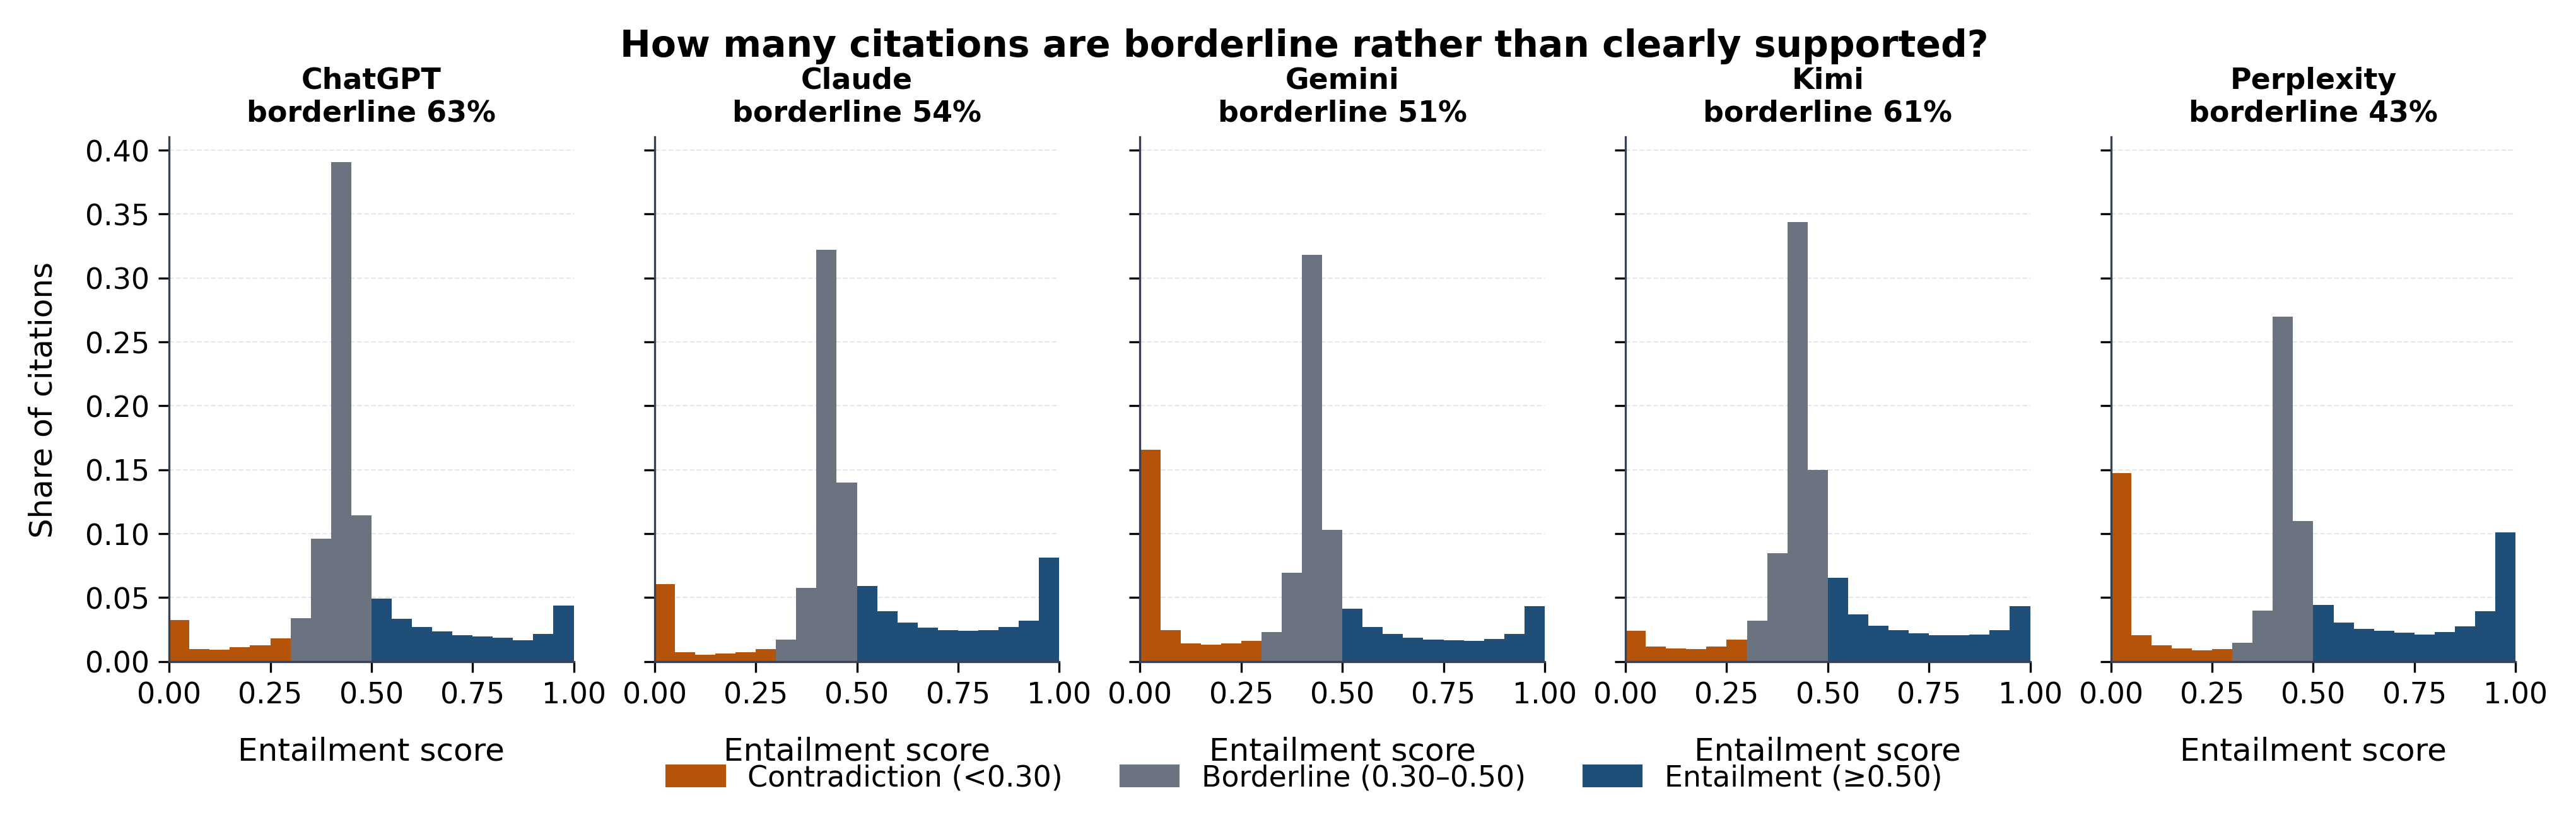

In [3]:
# Q13 · Citation support bands per engine. MAIN: horizontal stacked bars; APPENDIX: per-engine histograms.
eng = f1.set_index("response_id").engine
f4e = f4.assign(engine=f4.response_id.map(eng))

# --- band thresholds UNCHANGED: contradicted <0.30, borderline 0.30-0.50, clearly supported >=0.50 ---
def band_shares(sc):                                             # shares from the same scores/thresholds as histograms
    supported    = (sc >= 0.50).mean()
    borderline   = ((sc >= 0.30) & (sc < 0.50)).mean()
    contradicted = (sc < 0.30).mean()
    return supported, borderline, contradicted
shares = {e: band_shares(f4e.loc[f4e.engine == e, "entail_score"].values) for e in ENGINE_ORDER}
order  = sorted(ENGINE_ORDER, key=lambda e: shares[e][0], reverse=True)      # highest clearly-supported share on top

# --- neutral three-colour band scheme (NOT the engine palette) ---
BAND_SUPPORTED, BAND_BORDERLINE, BAND_CONTRADICTED = "#1F4E79", "#9AA3AF", "#C1504D"   # teal / grey / muted red
SEG = [("clearly supported", BAND_SUPPORTED, 0), ("borderline", BAND_BORDERLINE, 1), ("contradicted", BAND_CONTRADICTED, 2)]

# ---------- MAIN figure: horizontal stacked bar, one row per engine ----------
fig, ax = plt.subplots(figsize=(9.5, 5.0))
for yi, e in enumerate(order):
    left = 0.0
    for label, col, idx in SEG:
        val = shares[e][idx] * 100
        ax.barh(yi, val, left=left, height=0.62, color=col, edgecolor="white", linewidth=1.0)
        if val >= 3:
            ax.text(left + val / 2, yi, f"{val:.0f}%", va="center", ha="center", fontsize=10, fontweight="medium",
                    color="#374151" if col == BAND_BORDERLINE else "white")
        left += val
ax.set_yticks(range(len(order))); ax.set_yticklabels([ENGINE_LABELS[e] for e in order])
ax.invert_yaxis()                                                           # highest clearly-supported share at the top
ax.set_xlim(0, 100); ax.set_xlabel("Share of citations (%)")
ax.set_title("How many citations are borderline rather than clearly supported?")
apply_style(ax); ax.grid(False)
fig.legend(handles=[Patch(color=col, label=label) for label, col, _ in SEG], loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.06))
fig.text(0.5, -0.15, "Support bands (NLI): contradicted < 0.30  ·  borderline 0.30–0.50  ·  clearly supported ≥ 0.50",
         ha="center", fontsize=9, color="#6B7280")
savefig(fig, "fig_rq3_q13_entail_bands")

# ---------- APPENDIX figure: original per-engine histograms (indecisive -> borderline) ----------
BANDS = [("Contradiction (<0.30)", "#B45309", 0.0, 0.30), ("Borderline (0.30–0.50)", "#6B7280", 0.30, 0.50),
         ("Entailment (≥0.50)", "#1F4E79", 0.50, 1.0001)]
bins = np.arange(0, 1.0001, 0.05)                                                   # edges land on 0.30 and 0.50
figA, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=True)
for axh, e in zip(axes, ENGINE_ORDER):
    sc = f4e.loc[f4e.engine == e, "entail_score"].values; w = np.ones_like(sc) / len(sc)
    for _, col, lo, hi in BANDS:
        m = (sc >= lo) & (sc < hi); axh.hist(sc[m], bins=bins, weights=w[m], color=col)
    bl = ((sc >= 0.30) & (sc < 0.50)).mean() * 100
    axh.set_title(f"{ENGINE_LABELS[e]}\nborderline {bl:.0f}%", fontsize=11)
    axh.set_xlabel("Entailment score"); axh.set_xlim(0, 1); apply_style(axh)
axes[0].set_ylabel("Share of citations")
figA.legend(handles=[Patch(color=c, label=l) for l, c, _, _ in BANDS], loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.12))
figA.suptitle("How many citations are borderline rather than clearly supported?", y=1.04, fontweight="bold", fontsize=14)
savefig(figA, "fig_rq3_q13_entail_bands_appendix")

**Key analysis.** Each bar shows how confidently an engine's citations are supported: red = contradicted,
grey = borderline (the model itself is unsure), teal = clearly supported. The striking pattern is how much sits in
the grey middle — **between 43% (Perplexity) and 63% (ChatGPT) of all citations are borderline**, neither clearly
right nor clearly wrong. So most citations are not clean wins or clear errors; they are "maybe". Action: don't
treat a citation as proof your content was used correctly — about half the time even the model is on the fence.

saved fig_rq3_q14_sources_vs_ais


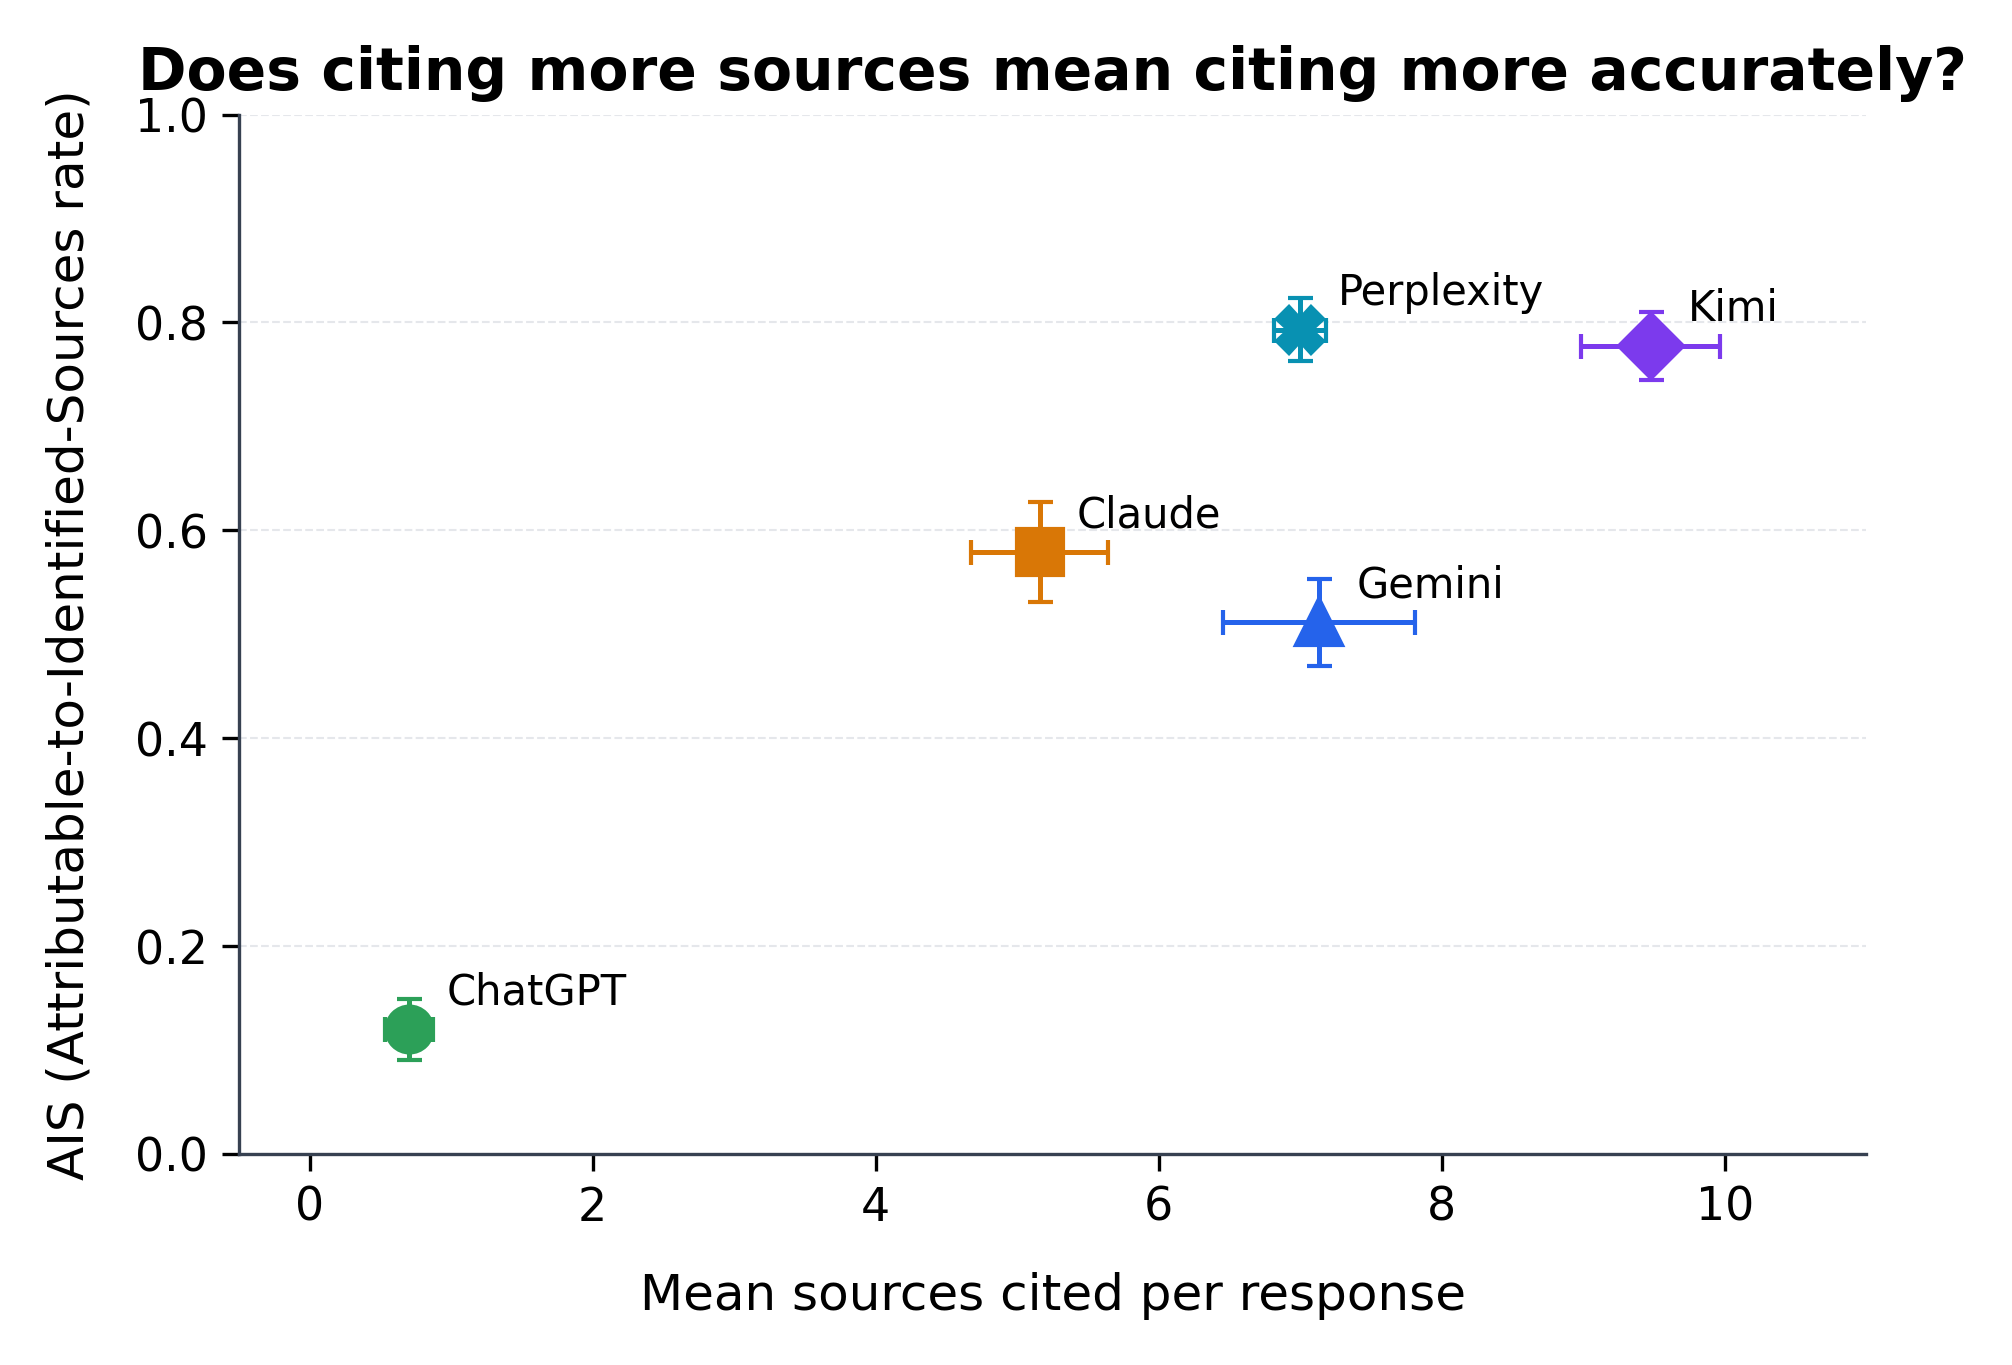

In [4]:
# Q14 · Sources cited vs AIS per engine, 95% CI across the engine's cells (n=5: read direction, no correlation stat).
def mean_ci(d, col):
    m = d[col].mean(); n = d[col].notna().sum(); return m, 1.96 * d[col].std(ddof=1) / np.sqrt(n)
fig, ax = plt.subplots()
for e in ENGINE_ORDER:
    d = ca[ca.engine == e]; xm, xci = mean_ci(d, "n_cited_mean"); ym, yci = mean_ci(d, "ais_mean")
    ax.errorbar(xm, ym, xerr=xci, yerr=yci, fmt=ENGINE_MARKERS[e], ms=11, color=ENGINE_COLOURS[e],
                ecolor=ENGINE_COLOURS[e], elinewidth=1.2, capsize=3, zorder=3)
    ax.annotate(ENGINE_LABELS[e], (xm, ym), textcoords="offset points", xytext=(9, 6), fontsize=10)
ax.set_xlabel("Mean sources cited per response")
ax.set_ylabel("AIS (Attributable-to-Identified-Sources rate)")
ax.set_title("Does citing more sources mean citing more accurately?")
ax.set_xlim(-0.5, 11); ax.set_ylim(0, 1); apply_style(ax)
savefig(fig, "fig_rq3_q14_sources_vs_ais")

**Key analysis.** Each point is one engine — how many sources it cites on average (right = more) against how
accurately it cites (up = more), with bars showing the range the true average likely falls in. Accuracy broadly
rises with volume, but **Gemini breaks the pattern: it cites heavily (about seven sources) yet is the second-least
accurate (0.51)**, while Perplexity reaches the highest accuracy (0.79) on fewer. Action: citing a lot is not the
same as citing well — on Gemini, more citations do not mean more trustworthy ones.

saved fig_rq3_q15_pawc_vs_ais_facets


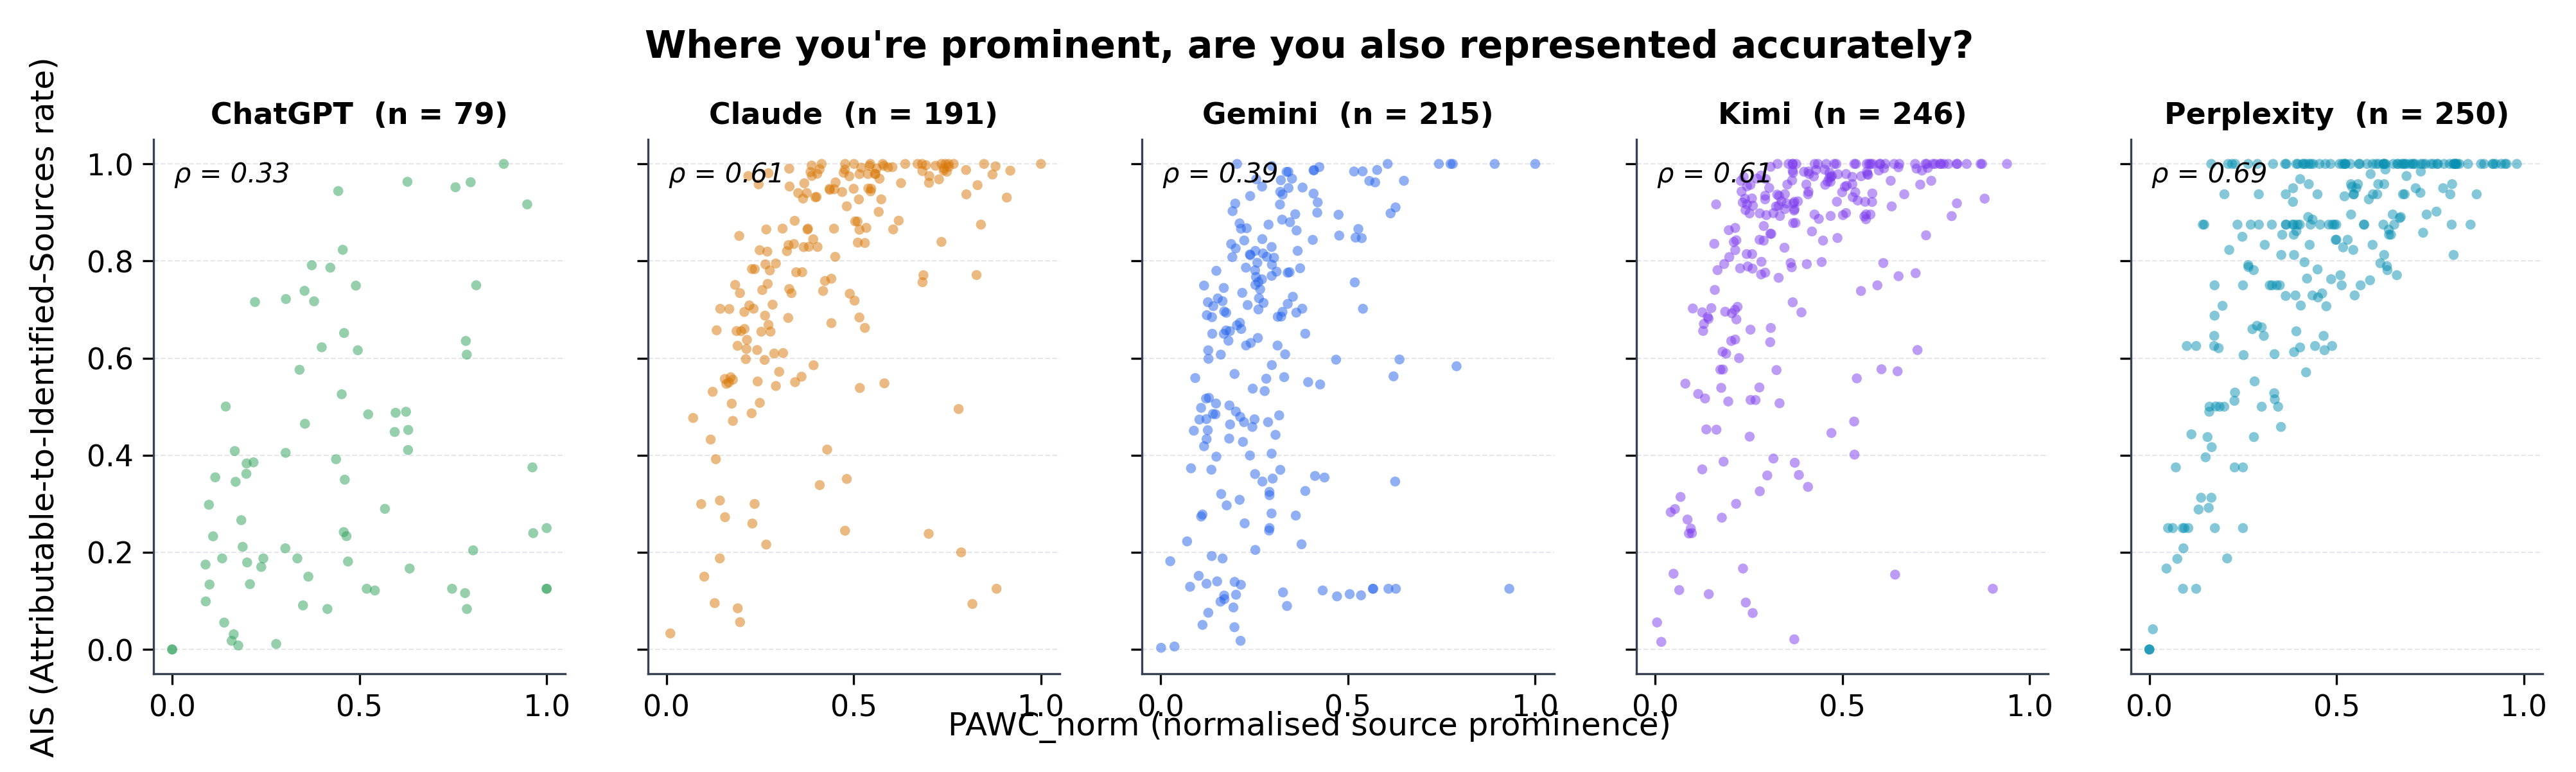

In [5]:
# Q15 · Per-engine: cell-level source prominence vs citation accuracy; Spearman rho annotated (defined cells).
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharex=True, sharey=True)
for ax, e in zip(axes, ENGINE_ORDER):
    d = ca[(ca.engine == e) & ca.pawc_norm_mean.notna()]
    ax.scatter(d.pawc_norm_mean, d.ais_mean, s=14, color=ENGINE_COLOURS[e], alpha=0.5, edgecolor="none")
    r, _ = spearmanr(d.pawc_norm_mean, d.ais_mean)
    ax.text(0.05, 0.92, f"ρ = {r:.2f}", transform=ax.transAxes, fontsize=10, fontstyle="italic")
    ax.set_title(f"{ENGINE_LABELS[e]}  (n = {len(d)})", fontsize=11); apply_style(ax)
axes[0].set_ylabel("AIS (Attributable-to-Identified-Sources rate)")
fig.supxlabel("PAWC_norm (normalised source prominence)", fontsize=12)
fig.suptitle("Where you're prominent, are you also represented accurately?", y=1.04, fontweight="bold", fontsize=14)
savefig(fig, "fig_rq3_q15_pawc_vs_ais_facets")

**Key analysis.** Each panel plots, for one engine, source prominence against citation accuracy across its
queries; an upward tilt means the queries where your content is most prominent are also the ones where it is most
accurately represented. That link is positive everywhere but **strongest on Perplexity, Kimi and Claude (around
0.6–0.7) and weakest on ChatGPT and Gemini (around 0.3–0.4)**. So on Perplexity and Kimi, winning visibility tends
to come with accurate representation; on Gemini the two drift apart. Action: on Gemini, check accuracy separately
even when your content is prominent.

saved fig_rq3_q16_ais_by_intent


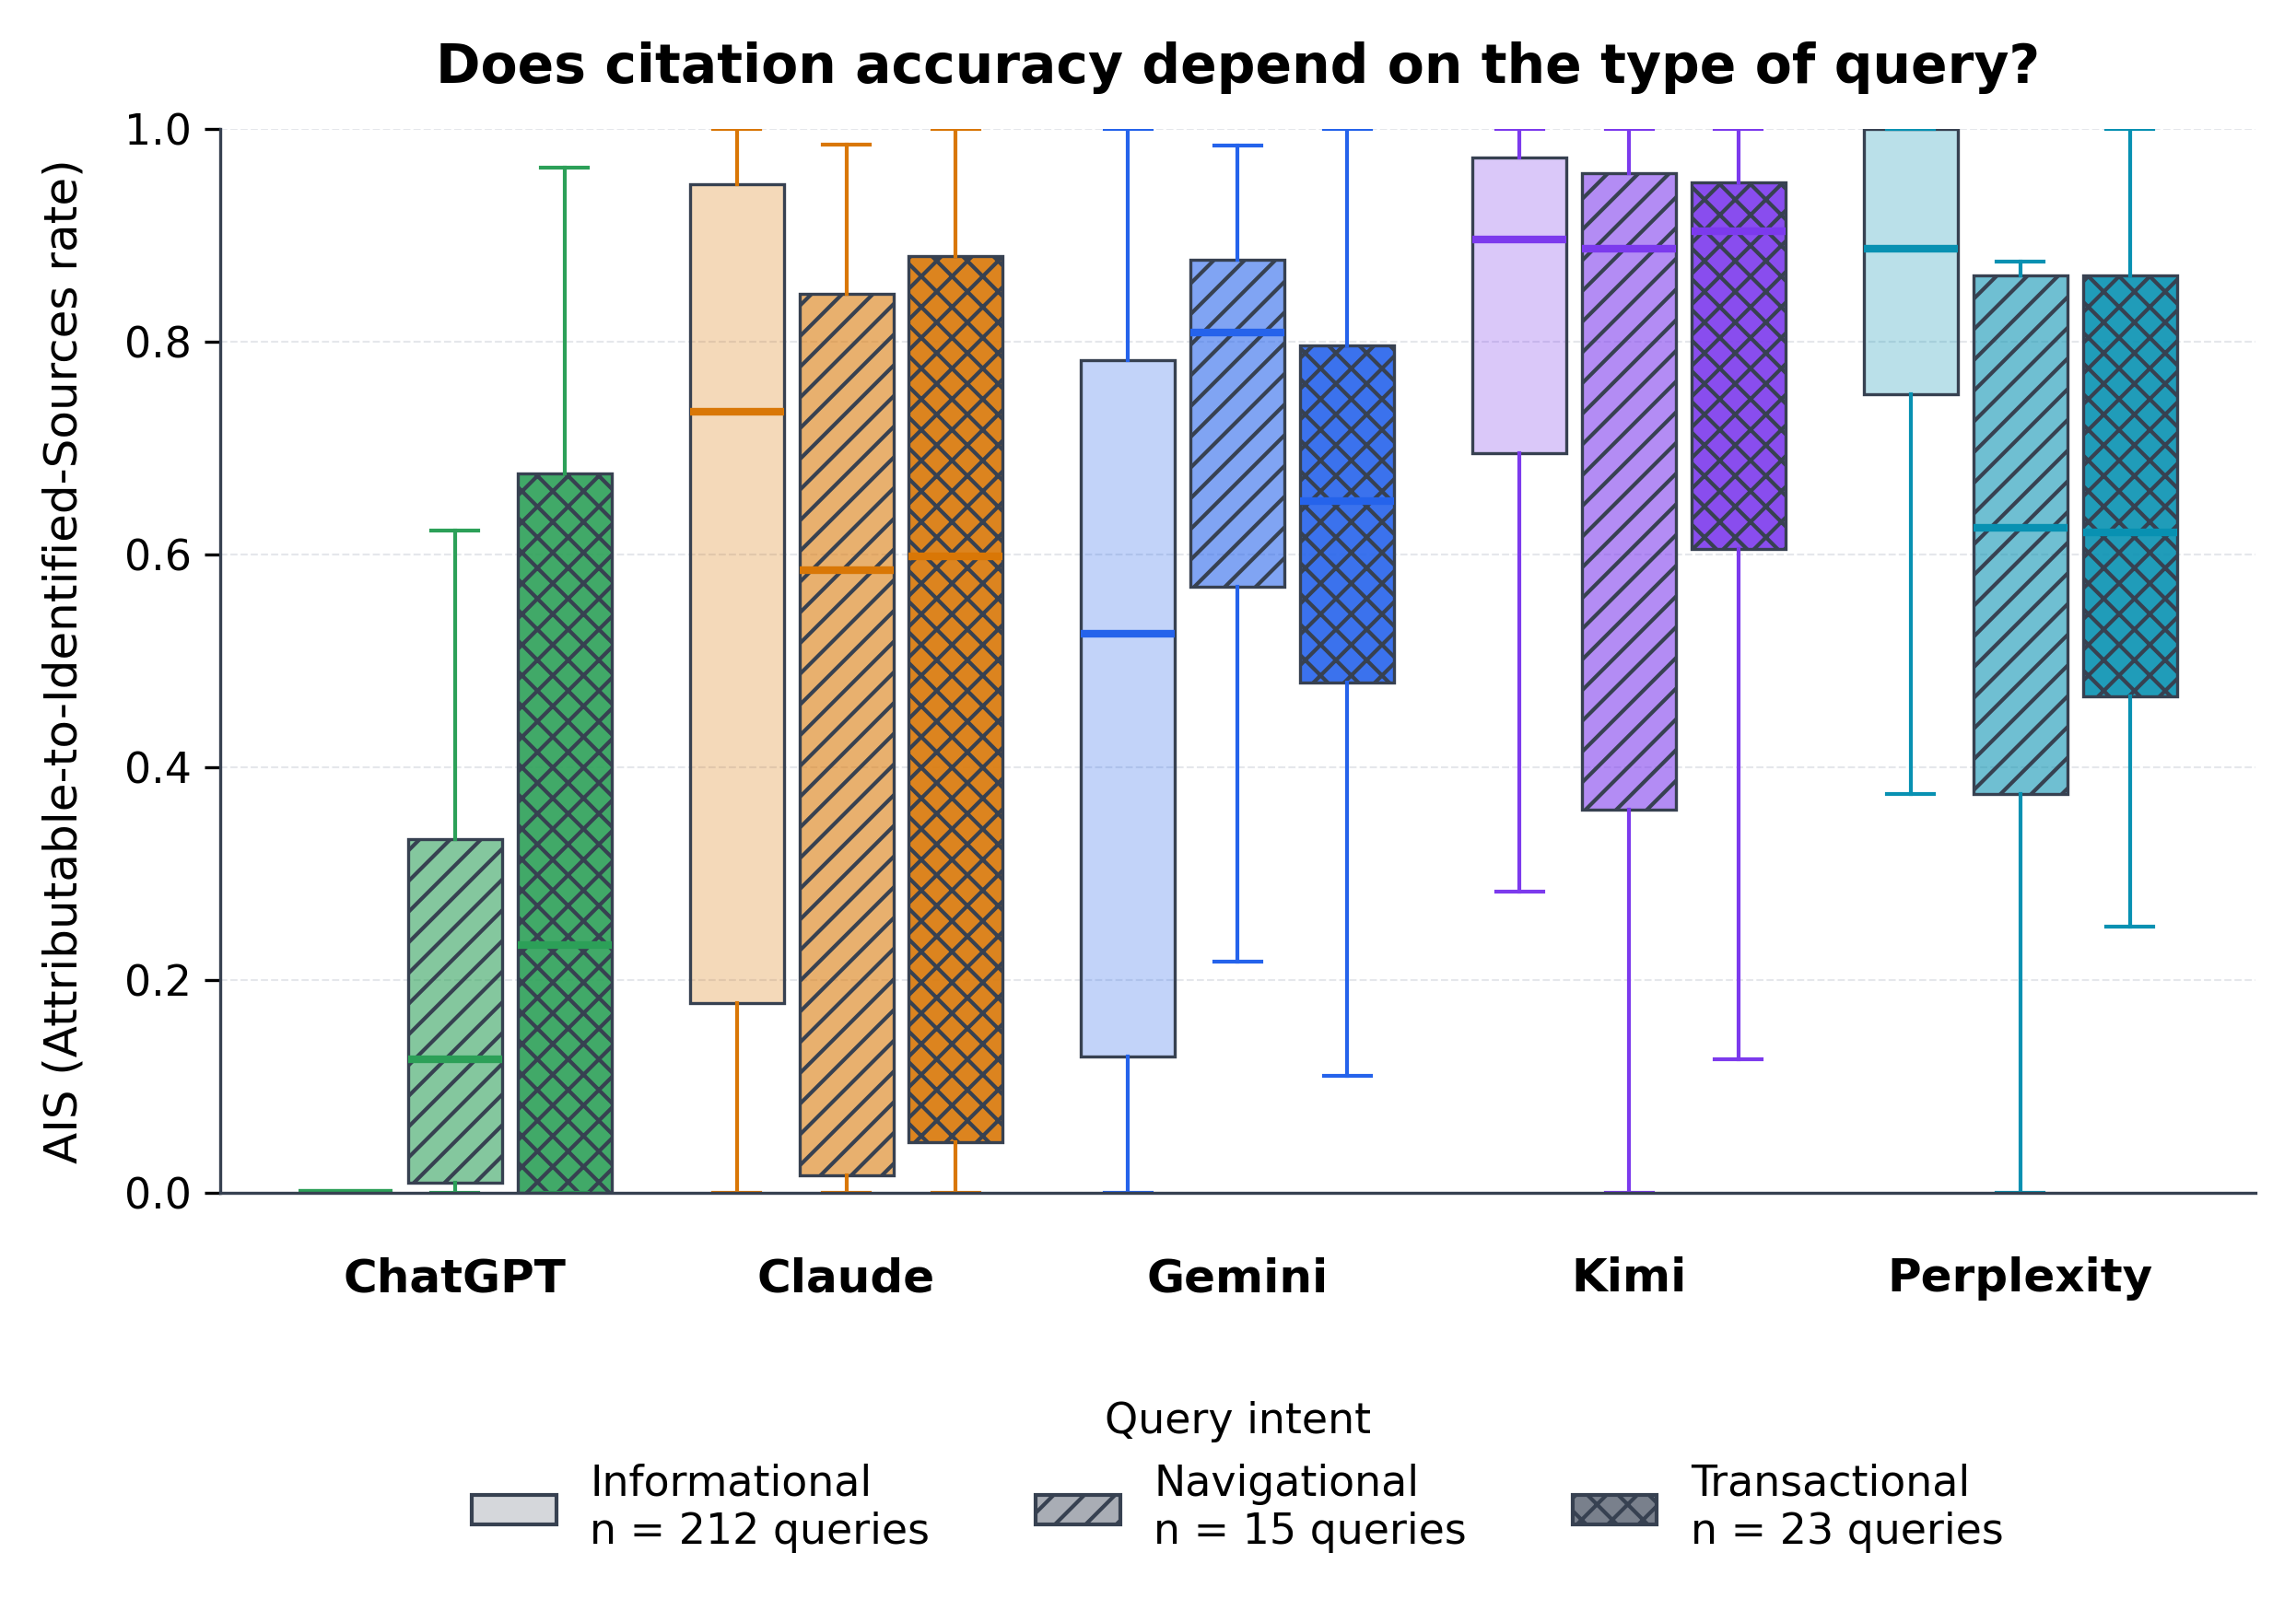

In [6]:
# Q16 · AIS by engine x query intent (cell-level ais_mean). Intent = shade + hatch; query n in legend (imbalanced).
d = ca.merge(qf, on="query_id")
intents = ["informational", "navigational", "transactional"]; nq = qf.intent.value_counts()
al  = {"informational": 0.28, "navigational": 0.58, "transactional": 0.90}
hat = {"informational": "",   "navigational": "///", "transactional": "xxx"}
fig, ax = plt.subplots(figsize=(9.5, 5.0))
for i, e in enumerate(ENGINE_ORDER):
    for j, it in enumerate(intents):
        vals = d[(d.engine == e) & (d.intent == it)].ais_mean.dropna().values; pos = i + (j - 1) * 0.28
        bp = ax.boxplot(vals, positions=[pos], widths=0.24, patch_artist=True, showfliers=False)
        bp["boxes"][0].set(facecolor=mpl.colors.to_rgba(ENGINE_COLOURS[e], al[it]), edgecolor="#374151", lw=0.8, hatch=hat[it])
        for m in bp["medians"]: m.set(color=ENGINE_COLOURS[e], lw=2)
        for wk in bp["whiskers"] + bp["caps"]: wk.set(color=ENGINE_COLOURS[e], lw=1)
    ax.text(i, -0.06, ENGINE_LABELS[e], transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=12, fontweight="semibold")
ax.set_xticks([]); ax.set_xlim(-0.6, 4.6); ax.set_ylim(0, 1)
ax.set_ylabel("AIS (Attributable-to-Identified-Sources rate)")
ax.set_title("Does citation accuracy depend on the type of query?", pad=12)
ax.legend(handles=[Patch(facecolor=mpl.colors.to_rgba(COLOUR_NEUTRAL, al[it]), edgecolor="#374151", hatch=hat[it],
                         label=f"{it.capitalize()}\nn = {int(nq[it])} queries") for it in intents],
          title="Query intent", loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, columnspacing=2.5)
apply_style(ax)
savefig(fig, "fig_rq3_q16_ais_by_intent")

**Key analysis.** Within each engine the boxes split accuracy by what the user wants — information, a specific
site, or to do something. Only informational queries are well-powered (212 of 250), and there the order matches the
headline: **Kimi and Perplexity are most accurate (medians of 0.90 and 0.89) and ChatGPT essentially zero**. The navigational
and transactional boxes rest on just 15 and 23 queries, so read them as hints, not findings. Action: anchor your
accuracy expectations on informational queries and confirm the smaller intent categories with a larger test.